# Notebook V5 - Prédiction d'intensité (composition corporelle)

Cette version V5 est construite à partir de la V4.

## Ce que V5 ajoute
- Intégration explicite de `Fat_Percentage`.
- Features de composition corporelle : `fat_mass_kg`, `lean_mass_kg`.
- Feature cardio-composition : `resting_to_lean_ratio`.
- Même rigueur d'évaluation que V4 (split stratifié, CV, métriques, confusion matrix).


## Pourquoi ce choix ?

Le poids seul ne distingue pas assez la composition corporelle.
À poids égal, un profil avec plus de masse grasse et un profil avec plus de masse maigre peuvent avoir des réponses cardiaques très différentes.
V5 vise à mieux capter cette nuance.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise RuntimeError('xgboost est requis: pip install xgboost') from exc


In [2]:
BASE_DIR = Path('/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML')
DATA_CANDIDATES = [
    BASE_DIR / 'gym_members_exercise_tracking_v2_realiste.csv',
    BASE_DIR / 'gym_members_exercise_tracking_v2.csv',
    BASE_DIR / 'gym_members_exercise_tracking.csv',
]


def resolve_data_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'Aucun fichier trouve parmi: {candidates}')


csv_path = resolve_data_path(DATA_CANDIDATES)
print('CSV utilise :', csv_path)

df_raw = pd.read_csv(csv_path)
print('Shape brut :', df_raw.shape)
df_raw.head()


CSV utilise : /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML/gym_members_exercise_tracking_v2.csv
Shape brut : (973, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,54,Male,61.0,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,20.86
1,49,Female,63.1,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,26.96
2,30,Female,65.8,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,23.88
3,23,Male,73.5,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,25.43
4,37,Male,73.4,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,22.91


## Contrôle de disponibilité de `Fat_Percentage`


In [3]:
required_cols = ['Fat_Percentage', 'Weight (kg)', 'Resting_BPM', 'Avg_BPM', 'Session_Duration (hours)', 'Workout_Type', 'Age']
missing_required = [c for c in required_cols if c not in df_raw.columns]

if missing_required:
    raise ValueError(f'Colonnes manquantes pour V5: {missing_required}')

print('OK - Colonnes V5 disponibles.')
df_raw[required_cols].describe(include='all').T


OK - Colonnes V5 disponibles.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Fat_Percentage,973.0,NaN,NaN,NaN,24.976773,6.259419,10.0,21.3,26.2,29.3,35.0
Weight (kg),973.0,NaN,NaN,NaN,77.704522,27.376472,32.0,61.4,73.1,88.1,182.0
Resting_BPM,973.0,NaN,NaN,NaN,62.223022,7.32706,50.0,56.0,62.0,68.0,74.0
Avg_BPM,973.0,NaN,NaN,NaN,143.766701,14.345101,120.0,131.0,143.0,156.0,169.0
Session_Duration (hours),973.0,NaN,NaN,NaN,1.256423,0.343033,0.5,1.04,1.26,1.46,2.0
Workout_Type,973,4,Strength,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,973.0,NaN,NaN,NaN,38.810894,15.723865,10.0,26.0,39.0,50.0,85.0


## Préparation V5 (alignée V4 + composition corporelle)


In [4]:
def to_intensity(score: pd.Series) -> pd.Series:
    q1, q2 = score.quantile([0.33, 0.66])

    def _map(x: float) -> str:
        if x <= q1:
            return 'faible'
        if x <= q2:
            return 'moyen'
        return 'eleve'

    return score.apply(_map)


def prepare_dataset_v5(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    # Nettoyage de base + bornes physiologiques
    data = data[
        (data['Age'].between(16, 80))
        & (data['Weight (kg)'].between(40, 170))
        & (data['Fat_Percentage'].between(5, 55))
        & (data['Session_Duration (hours)'].between(0.3, 3.0))
        & (data['Resting_BPM'].between(35, 110))
        & (data['Avg_BPM'].between(90, 210))
    ].copy()

    # Features V4
    hr_max_theorique = 220 - data['Age']
    denom = (hr_max_theorique - data['Resting_BPM']).replace(0, np.nan)
    data['hr_ratio_reserve'] = (data['Avg_BPM'] - data['Resting_BPM']) / denom
    data['bpm_reserve'] = data['Avg_BPM'] - data['Resting_BPM']
    data['effort_load'] = data['hr_ratio_reserve'] * data['Session_Duration (hours)'] * (data['Weight (kg)'] / 70.0)

    # Ajouts V5: composition corporelle
    data['fat_mass_kg'] = data['Weight (kg)'] * (data['Fat_Percentage'] / 100.0)
    data['lean_mass_kg'] = data['Weight (kg)'] - data['fat_mass_kg']
    data['resting_to_lean_ratio'] = data['Resting_BPM'] / data['lean_mass_kg'].replace(0, np.nan)

    # Score d'intensité V5: effort cardio + modulation composition
    intensity_score = (
        0.60 * data['hr_ratio_reserve']
        + 0.18 * (data['Session_Duration (hours)'] / 2.0)
        + 0.10 * ((data['Avg_BPM'] - 100.0) / 100.0)
        + 0.08 * ((data['fat_mass_kg'] / data['Weight (kg)']) - 0.22)
        + 0.04 * ((data['resting_to_lean_ratio'] * 10.0) - 0.8)
    )
    data['intensite'] = to_intensity(intensity_score)

    features = [
        'Age', 'Weight (kg)', 'Fat_Percentage', 'Avg_BPM', 'Resting_BPM',
        'Session_Duration (hours)', 'Workout_Type', 'hr_ratio_reserve',
        'bpm_reserve', 'effort_load', 'fat_mass_kg', 'lean_mass_kg',
        'resting_to_lean_ratio'
    ]

    model_df = data[features + ['intensite']].replace([np.inf, -np.inf], np.nan).dropna()
    return model_df


model_df = prepare_dataset_v5(df_raw)
print('Shape apres preparation V5 :', model_df.shape)
print(model_df['intensite'].value_counts(normalize=True).round(3))
model_df.head()


Shape apres preparation V5 : (889, 14)
intensite
eleve     0.340
faible    0.331
moyen     0.330
Name: proportion, dtype: float64


,Age,Weight (kg),Fat_Percentage,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,hr_ratio_reserve,bpm_reserve,effort_load,fat_mass_kg,lean_mass_kg,resting_to_lean_ratio,intensite
0,54,61.0,12.6,157,60,1.69,Yoga,0.915094,97,1.347673,7.6860,53.3140,1.125408,eleve
1,49,63.1,33.9,151,66,1.30,HIIT,0.809524,85,0.948646,21.3909,41.7091,1.582388,eleve
2,30,65.8,33.4,122,54,1.11,Cardio,0.500000,68,0.521700,21.9772,43.8228,1.232235,faible
3,23,73.5,28.8,164,56,0.59,Strength,0.765957,108,0.474511,21.1680,52.3320,1.070091,moyen
4,37,73.4,29.2,158,68,0.64,Strength,0.782609,90,0.525198,21.4328,51.9672,1.308518,eleve


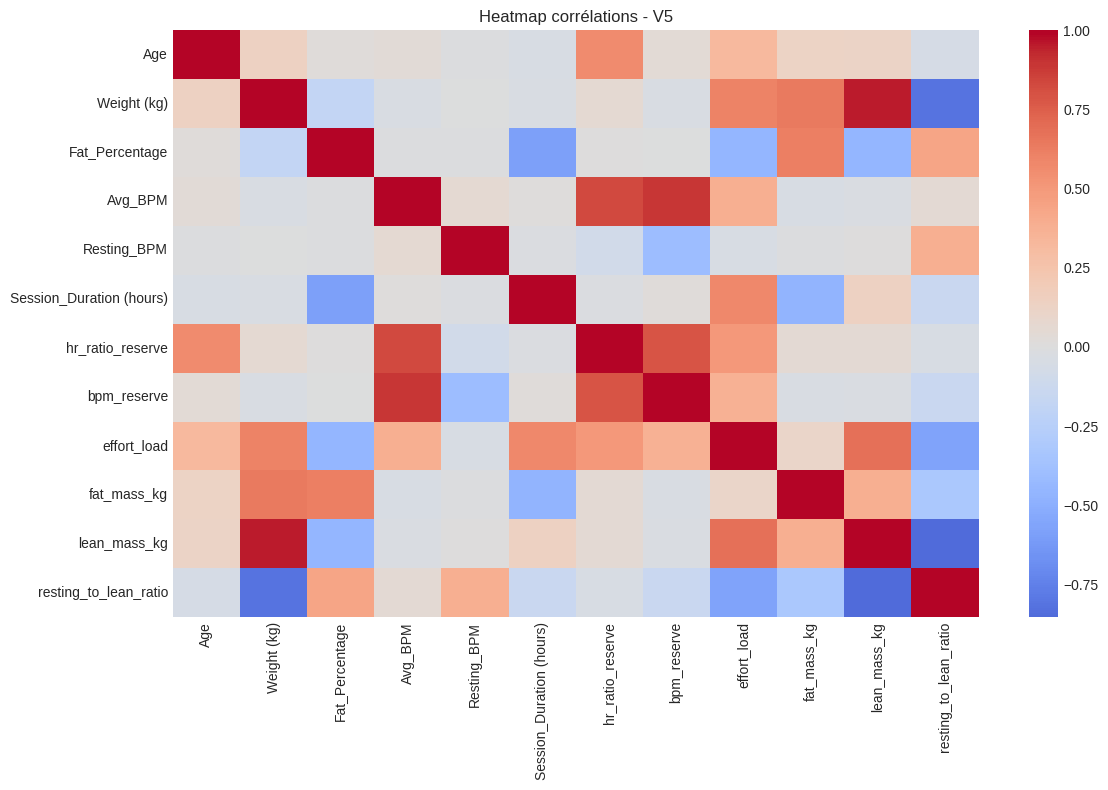

Corrélation Fat_Percentage vs Resting_BPM: -0.012
Corrélation fat_mass_kg vs Resting_BPM: -0.011
Corrélation lean_mass_kg vs Resting_BPM: 0.004
Corrélation resting_to_lean_ratio vs Resting_BPM: 0.386


In [5]:
# Corrélations des variables numériques
corr = model_df.select_dtypes(include=['number']).corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Heatmap corrélations - V5')
plt.tight_layout()
plt.show()

for col in ['Fat_Percentage', 'fat_mass_kg', 'lean_mass_kg', 'resting_to_lean_ratio']:
    if col in corr.columns:
        print(f"Corrélation {col} vs Resting_BPM: {corr.loc[col, 'Resting_BPM']:.3f}")


## Split et entraînement des 3 modèles


In [6]:
X_raw = model_df.drop(columns=['intensite']).copy()
y = model_df['intensite'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train_raw.shape, '| X_test:', X_test_raw.shape)
print('Distribution train:')
print(y_train.value_counts(normalize=True).round(3))


X_train: (711, 13) | X_test: (178, 13)
Distribution train:
intensite
eleve     0.340
faible    0.331
moyen     0.329
Name: proportion, dtype: float64


In [7]:
# Encodage pour RF/XGB
X_train_ohe = pd.get_dummies(X_train_raw, columns=['Workout_Type'], drop_first=True)
X_test_ohe = pd.get_dummies(X_test_raw, columns=['Workout_Type'], drop_first=True)
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
rf.fit(X_train_ohe, y_train)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=len(le.classes_),
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1,
)
xgb.fit(X_train_ohe, y_train_enc)

num_cols = [
    'Age', 'Weight (kg)', 'Fat_Percentage', 'Avg_BPM', 'Resting_BPM',
    'Session_Duration (hours)', 'hr_ratio_reserve', 'bpm_reserve',
    'effort_load', 'fat_mass_kg', 'lean_mass_kg', 'resting_to_lean_ratio'
]
cat_cols = ['Workout_Type']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ]
)

lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(solver='lbfgs', max_iter=3000, class_weight='balanced', random_state=42)),
])
lr.fit(X_train_raw, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Évaluation test


In [8]:
def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    print(f'[{name}] Accuracy: {acc:.4f} | F1 macro: {f1m:.4f}')
    print(classification_report(y_true, y_pred, digits=4))
    return {'Modele': name, 'Accuracy': acc, 'F1_macro': f1m}

rf_pred = rf.predict(X_test_ohe)
xgb_pred = le.inverse_transform(xgb.predict(X_test_ohe))
lr_pred = lr.predict(X_test_raw)

res_test = [
    evaluate_classifier('RandomForest', y_test, rf_pred),
    evaluate_classifier('XGBoost', y_test, xgb_pred),
    evaluate_classifier('LogisticRegression', y_test, lr_pred),
]

results_test_df = pd.DataFrame(res_test).sort_values('F1_macro', ascending=False)
display(results_test_df.style.format({'Accuracy': '{:.4f}', 'F1_macro': '{:.4f}'}))


[RandomForest] Accuracy: 0.8933 | F1 macro: 0.8954
              precision    recall  f1-score   support

       eleve     0.9630    0.8667    0.9123        60
      faible     0.9808    0.8644    0.9189        59
       moyen     0.7778    0.9492    0.8550        59

    accuracy                         0.8933       178
   macro avg     0.9072    0.8934    0.8954       178
weighted avg     0.9075    0.8933    0.8955       178

[XGBoost] Accuracy: 0.9382 | F1 macro: 0.9384
              precision    recall  f1-score   support

       eleve     0.9661    0.9500    0.9580        60
      faible     0.9649    0.9322    0.9483        59
       moyen     0.8871    0.9322    0.9091        59

    accuracy                         0.9382       178
   macro avg     0.9394    0.9381    0.9384       178
weighted avg     0.9395    0.9382    0.9386       178

[LogisticRegression] Accuracy: 0.9719 | F1 macro: 0.9720
              precision    recall  f1-score   support

       eleve     0.9833    0.

,Modele,Accuracy,F1_macro
2,LogisticRegression,0.9719,0.9720
1,XGBoost,0.9382,0.9384
0,RandomForest,0.8933,0.8954


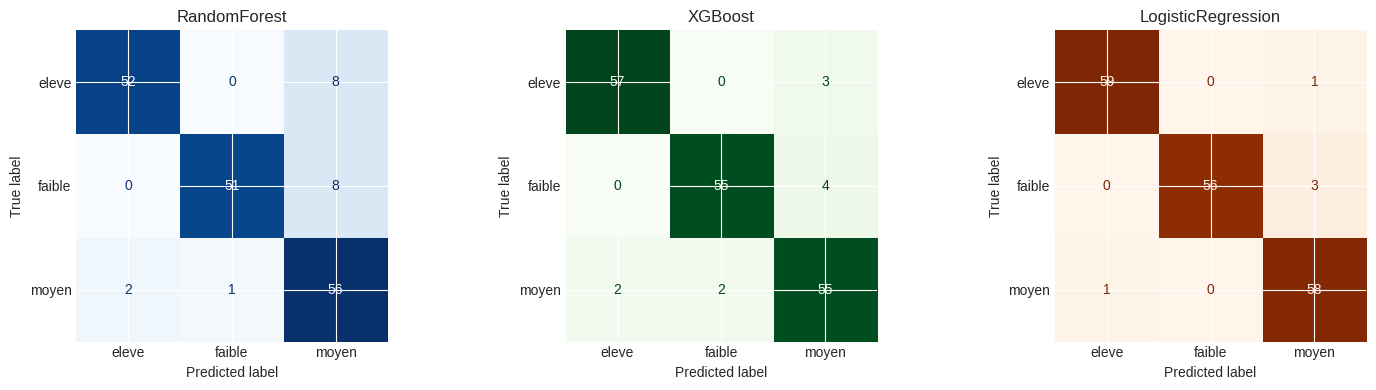

In [9]:
labels = sorted(y.unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, pred, cmap in [
    (axes[0], 'RandomForest', rf_pred, 'Blues'),
    (axes[1], 'XGBoost', xgb_pred, 'Greens'),
    (axes[2], 'LogisticRegression', lr_pred, 'Oranges'),
]:
    cm = confusion_matrix(y_test, pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Validation croisée (5 folds)


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_ohe_full = pd.get_dummies(X_raw, columns=['Workout_Type'], drop_first=True)

rf_cv = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced', n_jobs=-1)
rf_scores = cross_val_score(rf_cv, X_ohe_full, y, cv=cv, scoring='f1_macro')

y_enc_full = LabelEncoder().fit_transform(y)
xgb_cv = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1,
)
xgb_scores = cross_val_score(xgb_cv, X_ohe_full, y_enc_full, cv=cv, scoring='f1_macro')

lr_scores = cross_val_score(lr, X_raw, y, cv=cv, scoring='f1_macro')

cv_results = pd.DataFrame({
    'Modele': ['RandomForest', 'XGBoost', 'LogisticRegression'],
    'F1_macro_mean': [rf_scores.mean(), xgb_scores.mean(), lr_scores.mean()],
    'F1_macro_std': [rf_scores.std(), xgb_scores.std(), lr_scores.std()],
}).sort_values('F1_macro_mean', ascending=False)

display(cv_results.style.format({'F1_macro_mean': '{:.4f}', 'F1_macro_std': '{:.4f}'}))


,Modele,F1_macro_mean,F1_macro_std
2,LogisticRegression,0.9684,0.0132
1,XGBoost,0.9098,0.0202
0,RandomForest,0.9029,0.0153


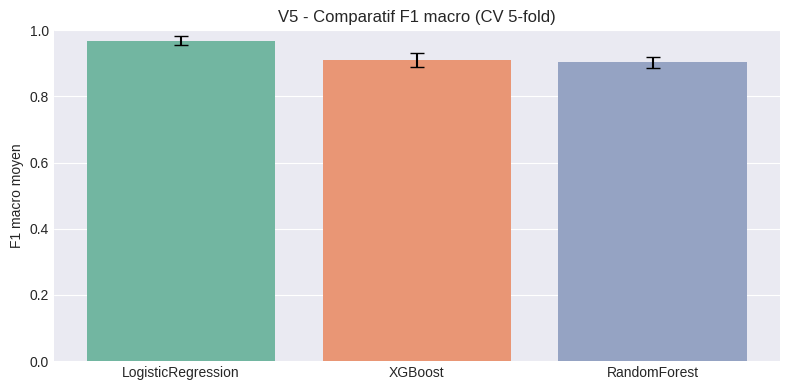

In [11]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_results, x='Modele', y='F1_macro_mean', palette='Set2')
for i, row in cv_results.reset_index(drop=True).iterrows():
    plt.errorbar(i, row['F1_macro_mean'], yerr=row['F1_macro_std'], fmt='none', c='black', capsize=5)
plt.ylim(0.0, 1.0)
plt.title('V5 - Comparatif F1 macro (CV 5-fold)')
plt.xlabel('')
plt.ylabel('F1 macro moyen')
plt.tight_layout()
plt.show()


## Interprétation orientée soutenance

- V5 explicite l'effet de la composition corporelle au-delà du poids brut.
- `Fat_Percentage` et `lean_mass_kg` peuvent mieux contextualiser `Resting_BPM`.
- Si les scores montent par rapport à V4, l'hypothèse métier est renforcée.


In [12]:
# Optionnel: sauvegarder les artefacts V5
# import joblib
# artifacts_dir = BASE_DIR / 'artifacts_intensite_v5'
# artifacts_dir.mkdir(exist_ok=True)
#
# joblib.dump(rf, artifacts_dir / 'rf_v5.joblib')
# joblib.dump(xgb, artifacts_dir / 'xgb_v5.joblib')
# joblib.dump(lr, artifacts_dir / 'lr_v5.joblib')
# joblib.dump(le, artifacts_dir / 'label_encoder_xgb_v5.joblib')
# pd.Series(X_train_ohe.columns).to_csv(artifacts_dir / 'rf_xgb_columns_v5.csv', index=False)
# print('Artefacts V5 sauvegardes dans', artifacts_dir)


## Conclusion

V5 garde la base robuste de V4 et introduit une meilleure représentation de la composition corporelle.
La décision finale (V4 ou V5) doit être guidée par la comparaison des scores CV et la cohérence métier des prédictions.
